# Lasso Regression

Lasso Regression (Least Absolute Shrinkage and Selection Operator) is a linear regression technique that prevents overfitting by adding an \(L1\) penalty to the cost function. It shrinks less significant feature coefficients exactly to zero, performing automatic feature selection and producing simpler, more interpretable models

## Import libraries and dataset


In [81]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

In [82]:
#Importing the dataset
df = pd.read_csv('/content/Advertising (1).csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Define variables and split into train and test set


In [83]:
X = df[['TV','Radio','Newspaper']] #Features(Independent variables)
y = df['Sales'] #Target(Dependent variable)

In [84]:
# 70% train, 30% temp
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


##Apply lasso regression

In [86]:
lasso_model = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_model.fit(x_train, y_train)  # Use SCALED data

MSE_train = mean_squared_error(y_train, lasso_model.predict(x_train))
r2_train = lasso_model.score(x_train, y_train)

print(f"Best Alpha = {lasso_model.alpha_}")
print(f"R2 Score (Train): {r2_train:.4f}")

Best Alpha = 0.05951504753162921
R2 Score (Train): 0.8954


In [87]:
y_pred = lasso_model.predict(x_test)
MSE_test = mean_squared_error(y_test, y_pred)
print(f"MSE (Test): {MSE_test:.4f}")

MSE (Test): 3.1823


Plot coefficients vs column names

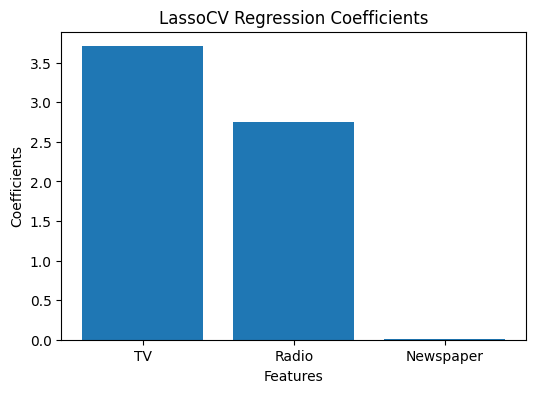

In [88]:
coefficients = lasso_model.coef_ #Store coefficients

plt.figure(figsize=(6,4))
plt.bar(X.columns, coefficients)
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title(f"LassoCV Regression Coefficients")
plt.show()

Alpha = 0.0010 | Coefficients = [3.76324261 2.79164909 0.05524889]
Alpha = 0.0016 | Coefficients = [3.76264993 2.79123204 0.05479827]
Alpha = 0.0026 | Coefficients = [3.76168754 2.79055485 0.05406657]
Alpha = 0.0043 | Coefficients = [3.76012483 2.78945523 0.05287844]
Alpha = 0.0070 | Coefficients = [3.75756995 2.78772606 0.05092765]
Alpha = 0.0113 | Coefficients = [3.75345075 2.78482316 0.04779635]
Alpha = 0.0183 | Coefficients = [3.7467621  2.78010951 0.04271182]
Alpha = 0.0298 | Coefficients = [3.73590121 2.77245558 0.03445568]
Alpha = 0.0483 | Coefficients = [3.71826557 2.76002731 0.02104955]
Alpha = 0.0785 | Coefficients = [3.68962947 2.7395704  0.        ]
Alpha = 0.1274 | Coefficients = [3.6431803  2.69312123 0.        ]
Alpha = 0.2069 | Coefficients = [3.56775721 2.61769814 0.        ]
Alpha = 0.3360 | Coefficients = [3.44528696 2.49522789 0.        ]
Alpha = 0.5456 | Coefficients = [3.24642261 2.29636354 0.        ]
Alpha = 0.8859 | Coefficients = [2.9235113  1.97345224 0.     

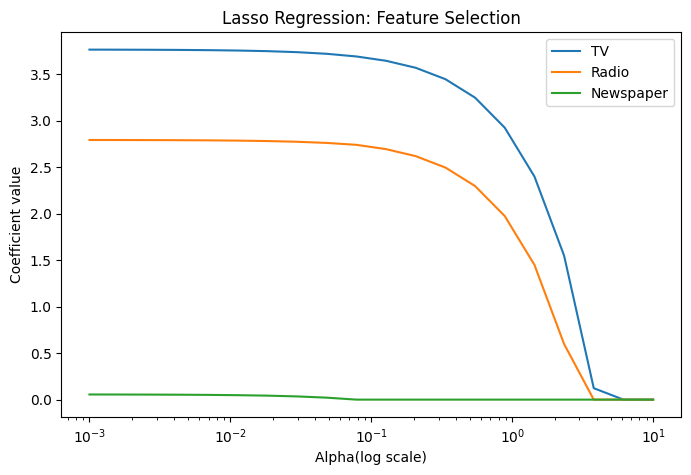

In [90]:
#Generate alpha values on log scale
alphas = np.logspace(-3, 1, 20)

#Store coefficients
coefficients_path = []

for alpha_value in alphas:
  lasso_model = LassoCV(alphas=[alpha_value], max_iter=5000)
  lasso_model.fit(x_train, y_train)
  coefficients_path.append(lasso_model.coef_)

  print(f"Alpha = {alpha_value:.4f} | Coefficients = {lasso_model.coef_}") #Printing coefficients

coefficients_path = np.array(coefficients_path) #Convert to numpy array

#plot
plt.figure(figsize=(8,5))
plt.plot(alphas, coefficients_path)
plt.xscale('log')
plt.xlabel('Alpha(log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regression: Feature Selection')
plt.legend(X.columns)